# Pix2Pix Final Project - Test Environment

This notebook is the test environment for the final trained model.

The notebook:
1. Downloads the trained generator model from Google Drive using `gdown`.
2. Loads the model with TensorFlow/Keras.
3. Receives a **128x128 sketch image** from the user.
4. Preprocesses the sketch exactly like in training.
5. Generates a 128x128 RGB flower image.
6. Displays the input sketch and the generated output.

</br>

**Best Model Information**

We use the best trained Pix2Pix generator model (Small PatchGAN discriminator).

Reason for selection:
This model achieved the best balance between validation L1 loss and visual quality.

#Prep Work

In [ ]:
%%capture
!pip install ipython-autotime
%load_ext autotime

time: 311 µs (started: 2026-05-18 17:02:59 +00:00)


In [ ]:
!pip install -q gdown

time: 4.19 s (started: 2026-05-18 17:02:59 +00:00)


In [ ]:
import os
import cv2
import gdown
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from google.colab import files
from pathlib import Path

time: 4.04 s (started: 2026-05-18 17:03:03 +00:00)


##Global Parameters

In [ ]:
IMG_SIZE = 128
MODEL_DIR = Path("/content/model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "best_generator.keras"

time: 805 µs (started: 2026-05-18 17:03:07 +00:00)


##Download Model with gdown

In [ ]:
MODEL_FILE_ID = "1S2-0l2kgPqC2FHkBGVz5wpcBXLLzcMAH"

model_url = f"https://drive.google.com/uc?id={MODEL_FILE_ID}"

gdown.download(
    model_url,
    str(MODEL_PATH),
    quiet=False
)

print("Model downloaded successfully.")

Downloading...
From (original): https://drive.google.com/uc?id=1S2-0l2kgPqC2FHkBGVz5wpcBXLLzcMAH
From (redirected): https://drive.google.com/uc?id=1S2-0l2kgPqC2FHkBGVz5wpcBXLLzcMAH&confirm=t&uuid=8db5b1ce-609a-4c91-9d2d-299971a1416f
To: /content/model/best_generator.keras
100%|██████████| 168M/168M [00:04<00:00, 40.3MB/s]

Model downloaded successfully.
time: 7.81 s (started: 2026-05-18 17:03:07 +00:00)


##Load Model

In [ ]:
generator = keras.models.load_model(MODEL_PATH, compile=False)

print("Model loaded successfully.")


Model loaded successfully.
time: 4.05 s (started: 2026-05-18 17:03:15 +00:00)


In [ ]:
generator.summary()

Model: "pix2pix_unet_generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ generator_input_sk… │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_down_1          │ (None, 64, 64,    │      1,024 │ generator_input_… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_down_2          │ (None, 32, 32,    │    131,584 │ gen_down_1[0][0]  │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_down_3          │ (None, 16, 16,    │    525,312 │ gen_down_2[0][0]  │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_down_4          │ (None, 8, 8, 512) │  2,099,200 │ gen_down_3[0][0]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_down_5          │ (None, 4, 4, 512) │  4,196,352 │ gen_down_4[0][0]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_down_6          │ (None, 2, 2, 512) │  4,196,352 │ gen_down_5[0][0]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_bottleneck      │ (None, 1, 1, 512) │  4,196,352 │ gen_down_6[0][0]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_up_1            │ (None, 2, 2, 512) │  4,196,352 │ gen_bottleneck[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_skip_connectio… │ (None, 2, 2,      │          0 │ gen_up_1[0][0],   │
│ (Concatenate)       │ 1024)             │            │ gen_down_6[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_up_2            │ (None, 4, 4, 512) │  8,390,656 │ gen_skip_connect… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_skip_connectio… │ (None, 4, 4,      │          0 │ gen_up_2[0][0],   │
│ (Concatenate)       │ 1024)             │            │ gen_down_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_up_3            │ (None, 8, 8, 512) │  8,390,656 │ gen_skip_connect… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_skip_connectio… │ (None, 8, 8,      │          0 │ gen_up_3[0][0],   │
│ (Concatenate)       │ 1024)             │            │ gen_down_4[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_up_4            │ (None, 16, 16,    │  4,195,328 │ gen_skip_connect… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_skip_connectio… │ (None, 16, 16,    │          0 │ gen_up_4[0][0],   │
│ (Concatenate)       │ 512)              │            │ gen_down_3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gen_up_5            │ (None, 32, 32,    │  1,049,088 │ gen_skip_connect

 Total params: 41,836,803 (159.59 MB)

 Trainable params: 41,827,971 (159.56 MB)

 Non-trainable params: 8,832 (34.50 KB)

time: 27.4 ms (started: 2026-05-18 17:03:19 +00:00)


###Helper Functions

* **Normelize sktch:** normelize sketch image from [0, 255] to [-1, 1]
* **Denormelize image:** Convert generated image from [-1, 1] to [0, 1]

In [ ]:
def normalize_sketch(sketch):
    sketch = sketch.astype(np.float32)
    sketch = sketch / 127.5 - 1.0
    return sketch


def denormalize_image(image):
    image = (image + 1.0) / 2.0
    image = np.clip(image, 0.0, 1.0)
    return image

time: 631 µs (started: 2026-05-18 17:03:19 +00:00)


#Upload Sketch Image

In [ ]:
uploaded = files.upload()

uploaded_filename = list(uploaded.keys())[0]
print("Uploaded file:", uploaded_filename)

Saving f-i.png to f-i.png
Uploaded file: f-i.png
time: 20.7 s (started: 2026-05-18 17:03:19 +00:00)


##Preprocess Uploaded Sketch

Loads a user sketch image and prepares it for the generator.

Expected model input:
shape: (1, 128, 128, 1) </br>
value range: [-1, 1]

In [ ]:
def preprocess_uploaded_sketch(image_path):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    print("Original upload shape:", img.shape)
    print("------------------------------------------")

    if img is None:
        raise ValueError("Could not read the uploaded image.")

    if img.shape != (IMG_SIZE, IMG_SIZE):
      img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
      print("Shape after resize:", img.shape)
      print("------------------------------------------")


    normalized = normalize_sketch(img)

    normalized = np.expand_dims(normalized, axis=-1)
    normalized = np.expand_dims(normalized, axis=0)

    return img, normalized


original_sketch, model_input = preprocess_uploaded_sketch(uploaded_filename)

print("Original sketch shape:", original_sketch.shape)
print("Model input shape:", model_input.shape)
print("Model input range:", model_input.min(), "to", model_input.max())

Original upload shape: (506, 506)
------------------------------------------
Shape after resize: (128, 128)
------------------------------------------
Original sketch shape: (128, 128)
Model input shape: (1, 128, 128, 1)
Model input range: -0.9372549 to 1.0
time: 43.8 ms (started: 2026-05-18 17:03:40 +00:00)


##Generate Image

In [ ]:
generated = generator.predict(model_input, verbose=0)

generated_image = generated[0]
generated_image = denormalize_image(generated_image)

print("Generated image shape:", generated_image.shape)

Generated image shape: (128, 128, 3)
time: 3.48 s (started: 2026-05-18 17:03:40 +00:00)


##Display Result

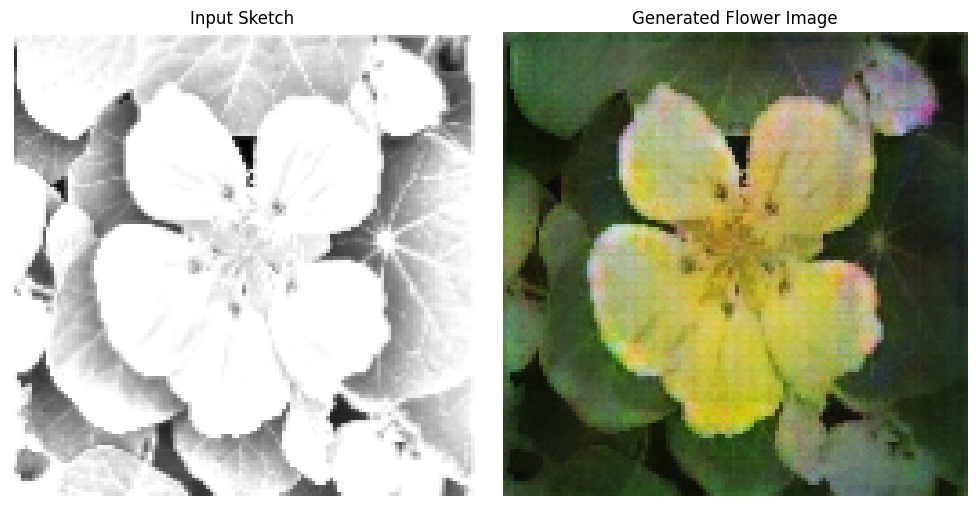

time: 211 ms (started: 2026-05-18 17:03:44 +00:00)


In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_sketch, cmap="gray")
plt.title("Input Sketch")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(generated_image)
plt.title("Generated Flower Image")
plt.axis("off")

plt.tight_layout()
plt.show()